In [6]:
import pandas as pd
train = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/train.csv')
train_labels = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/train_labels.csv')
target_pairs = pd.read_csv('/Users/hayden/coderepos_mac_mini/mitsui_commodity/data/target_pairs.csv')
train.head()

,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
0,0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037
3,3,2202.5,7121.0,2540.0,3354.0,4728.0,4737.0,4729.0,3430.0,3426.0,...,1.683111,0.785329,0.889439,0.698502,0.067639,0.091558,0.121021,0.079285,14.035571,0.059983
4,4,2175.0,7125.0,2604.0,3386.0,NaN,NaN,NaN,NaN,NaN,...,1.684816,0.787264,0.891042,0.701485,0.067443,0.091266,0.121055,0.078925,14.013760,0.059503


In [5]:
#find first non-null value in each column
train.notnull().idxmax()
#find last non-null value in each column
train.notnull()[::-1].idxmax()

date_id         1960
LME_AH_Close    1960
LME_CA_Close    1960
LME_PB_Close    1960
LME_ZS_Close    1960
                ... 
FX_NOKGBP       1960
FX_NOKCHF       1960
FX_ZARCHF       1960
FX_NOKJPY       1960
FX_ZARGBP       1960
Length: 558, dtype: int64

In [8]:
#okay so thers just random missing values but for most of them its not mroe than like 6%
#give me the columsn where null is more than 6%
null_percent = train.isnull().mean()
null_percent[null_percent > 0.06]

US_Stock_GOLD_adj_open      0.873534
US_Stock_GOLD_adj_high      0.873534
US_Stock_GOLD_adj_low       0.873534
US_Stock_GOLD_adj_close     0.873534
US_Stock_GOLD_adj_volume    0.873534
dtype: float64

Text(0.5, 1.0, 'Missing Values Heatmap')

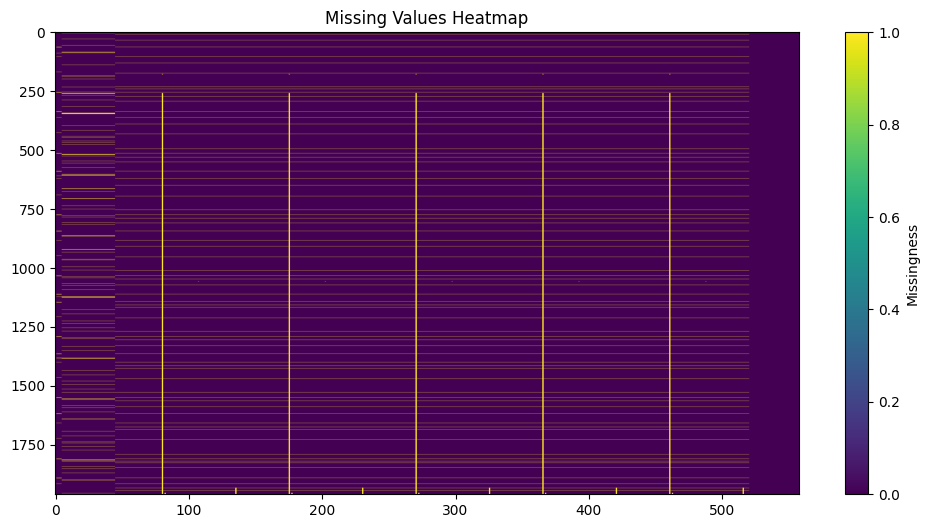

In [11]:
#Plot a missingness heatmap (matplotlib imshow on df.isnull())
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.imshow(train.isnull(), aspect='auto', cmap='viridis')
plt.colorbar(label='Missingness')
plt.title('Missing Values Heatmap')

In [ ]:
# the first block is the jpx exchange assets and has different missingness patterns than the rest. 
# the four lines are the GOLD asset, which has mostly missing values because it didnt go public (i think) until later in the competition

In [15]:
labels = train_labels
pairs = target_pairs

print(pairs['lag'].value_counts())
print(pairs['pair'].str.contains(' - ').value_counts())
# True  = pair spread, False = single asset

lag
1    106
2    106
3    106
4    106
Name: count, dtype: int64
pair
True     420
False      4
Name: count, dtype: int64


In [16]:
is_pair = pairs['pair'].str.contains(' - ')

single_asset_targets = pairs[~is_pair]  # just target_0 and any others
pair_targets = pairs[is_pair]           # the vast majority

print(f"Single asset: {len(single_asset_targets)}")
print(f"Pairs: {len(pair_targets)}")

Single asset: 4
Pairs: 420


In [18]:
def parse_pair(pair_str):
    if ' - ' in pair_str:
        a, b = pair_str.split(' - ')
        return a.strip(), b.strip()
    else:
        return pair_str.strip(), None  # single asset, no second leg

pairs[['asset_a', 'asset_b']] = pairs['pair'].apply(
    lambda x: pd.Series(parse_pair(x))
)

print(pairs[['target', 'pair', 'asset_a', 'asset_b']].head(5))

     target                                            pair  \
0  target_0                           US_Stock_VT_adj_close   
1  target_1            LME_PB_Close - US_Stock_VT_adj_close   
2  target_2                     LME_CA_Close - LME_ZS_Close   
3  target_3                     LME_AH_Close - LME_ZS_Close   
4  target_4  LME_AH_Close - JPX_Gold_Standard_Futures_Close   

                 asset_a                          asset_b  
0  US_Stock_VT_adj_close                              NaN  
1           LME_PB_Close            US_Stock_VT_adj_close  
2           LME_CA_Close                     LME_ZS_Close  
3           LME_AH_Close                     LME_ZS_Close  
4           LME_AH_Close  JPX_Gold_Standard_Futures_Close  
